# 02 — Deep Knowledge Tracing

An LSTM over the learner's interaction sequence. At each step the model receives the (skill, correctness) pair just observed and predicts P(correct) for every skill. The scored prediction is the one for the skill the learner encounters at the next step.

Validation AUC is computed on learners held out during data prep, which the encoder never observed. It estimates generalization to unseen learners.

In [32]:
import polars as pl, numpy as np, json
from pathlib import Path
import torch, torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import roc_auc_score

root = next(c for c in (Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent)
            if (c / "data" / "processed" / "meta.json").exists())
OUT = root / "data" / "processed"

N_SKILLS = json.loads((OUT / "meta.json").read_text())["n_skills"]
PAD, MAX_LEN = 2 * N_SKILLS, 200
DEVICE = ("mps" if torch.backends.mps.is_available()
          else "cuda" if torch.cuda.is_available() else "cpu")
print(DEVICE, "| n_skills", N_SKILLS)

mps | n_skills 142


### Encoding and architecture

Each input step encodes (skill `s`, correctness `c`) as `s + c·N_SKILLS`, giving an input vocabulary of `2·N_SKILLS` plus a padding index. An embedding feeds a single-layer LSTM, and a linear head projects the hidden state to one logit per skill. The answer to the predicted question never enters the input at that same step: inputs span positions `0…T-1`, targets span `1…T`. That offset is what avoids the standard DKT label leak.

Long histories are truncated to the most recent `MAX_LEN` interactions, on the assumption that recent responses are more predictive of the next one than early responses.

In [33]:
class DKT(nn.Module):
    # input = skill + correct*N_SKILLS in [0, 2N); hidden -> per-skill logits.
    def __init__(self, n, hidden=100, layers=1, dropout=0.2):
        super().__init__()
        self.embed = nn.Embedding(2*n + 1, hidden, padding_idx=2*n)
        self.lstm  = nn.LSTM(hidden, hidden, layers, batch_first=True,
                             dropout=dropout if layers > 1 else 0.0)
        self.drop  = nn.Dropout(dropout)
        self.out   = nn.Linear(hidden, n)
    def forward(self, x):
        h, _ = self.lstm(self.embed(x))
        return self.out(self.drop(h))

class KT(Dataset):
    def __init__(self, path, max_len=MAX_LEN):
        d = pl.read_parquet(path)
        self.s, self.r, self.max_len = d["skills"].to_list(), d["responses"].to_list(), max_len
    def __len__(self): return len(self.s)
    def __getitem__(self, i):
        s = np.array(self.s[i][-self.max_len:], dtype=np.int64)
        r = np.array(self.r[i][-self.max_len:], dtype=np.int64)
        x = (s[:-1] + r[:-1] * N_SKILLS).astype(np.int64)   # encode input step
        return x, s[1:], r[1:].astype(np.float32)           # target = next skill/correct

def collate(batch):
    xs, ns, nc = zip(*batch)
    L = max(map(len, xs))
    bx = np.full((len(batch), L), PAD, np.int64)
    bn = np.zeros((len(batch), L), np.int64)
    by = np.zeros((len(batch), L), np.float32)
    bm = np.zeros((len(batch), L), np.float32)              # mask real positions
    for i, (x, n, y) in enumerate(zip(xs, ns, nc)):
        k = len(x); bx[i,:k]=x; bn[i,:k]=n; by[i,:k]=y; bm[i,:k]=1.0
    return map(torch.tensor, (bx, bn, by, bm))

In [34]:
train_dl = DataLoader(KT(OUT/"train.parquet"), batch_size=64, shuffle=True,  collate_fn=collate)
val_dl   = DataLoader(KT(OUT/"val.parquet"),   batch_size=64, shuffle=False, collate_fn=collate)

model = DKT(N_SKILLS).to(DEVICE)
opt   = torch.optim.Adam(model.parameters(), lr=1e-3)
bce   = nn.BCEWithLogitsLoss(reduction="none")

### Training and evaluation

Loss is binary cross-entropy on the next-skill logit, masked so padded positions don't contribute. AUC is computed over all non-padded positions pooled across the split. Validation runs under `no_grad` with the same masking.

In [35]:
def epoch(dl, train):
    model.train(train)
    L, Y, P = [], [], []
    for bx, bn, by, bm in dl:
        bx, bn, by, bm = (z.to(DEVICE) for z in (bx, bn, by, bm))
        pred = model(bx).gather(2, bn.unsqueeze(2)).squeeze(2)   # logit for next skill
        loss = (bce(pred, by) * bm).sum() / bm.sum()             # mask out padding
        if train:
            opt.zero_grad(); loss.backward(); opt.step()
        m = bm.bool()
        L.append(loss.item())
        Y.append(by[m].detach().cpu().numpy())
        P.append(torch.sigmoid(pred)[m].detach().cpu().numpy())
    y, p = np.concatenate(Y), np.concatenate(P)
    return np.mean(L), (roc_auc_score(y, p) if len(np.unique(y)) > 1 else float("nan"))

hist = {"train": [], "val": []}
for e in range(1, 11):
    tl, ta = epoch(train_dl, True)
    with torch.no_grad():
        vl, va = epoch(val_dl, False)
    hist["train"].append(ta); hist["val"].append(va)
    print(f"{e:2d}  train {tl:.4f}/{ta:.4f}   val {vl:.4f}/{va:.4f}")

 1  train 0.6900/0.5289   val 0.6833/0.5691
 2  train 0.6768/0.5944   val 0.6743/0.5916
 3  train 0.6636/0.6250   val 0.6650/0.6064
 4  train 0.6503/0.6384   val 0.6571/0.6164
 5  train 0.6381/0.6452   val 0.6514/0.6269
 6  train 0.6288/0.6630   val 0.6461/0.6377
 7  train 0.6200/0.6828   val 0.6434/0.6455
 8  train 0.6179/0.6927   val 0.6406/0.6486
 9  train 0.6121/0.7025   val 0.6404/0.6548
10  train 0.6082/0.7143   val 0.6384/0.6554


### Training curve

Train and validation AUC both rise and stay close, with validation trailing train by a small margin. The gap reflects generalization to held-out learners rather than memorization. No turn upward in validation loss over these epochs, so there's no sign of overfitting at this length.

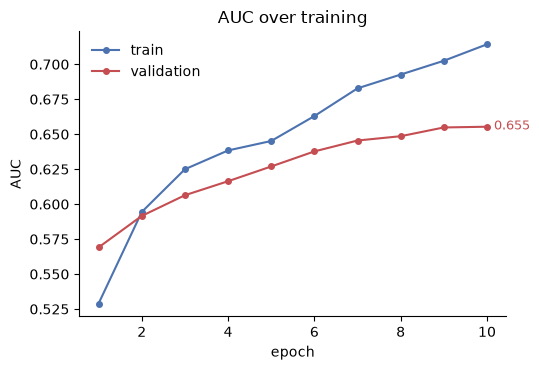

In [36]:
import matplotlib.pyplot as plt

FIG = root / "figures"; FIG.mkdir(exist_ok=True)

ep = range(1, len(hist["train"]) + 1)
fig, ax = plt.subplots(figsize=(5.5, 3.8))
ax.plot(ep, hist["train"], marker="o", markersize=4, color="#4C72B0", label="train")
ax.plot(ep, hist["val"], marker="o", markersize=4, color="#C44E52", label="validation")
ax.annotate(f"{hist['val'][-1]:.3f}", xy=(len(hist["val"]), hist["val"][-1]),
            xytext=(5, -2), textcoords="offset points", fontsize=9, color="#C44E52")
ax.set(xlabel="epoch", ylabel="AUC", title="AUC over training")
ax.legend(frameon=False); ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
fig.savefig(FIG / "auc_curve.png", dpi=130, bbox_inches="tight")
plt.show()